# Deep Learning-based Multi-Class Classification

## VGG · ResNet · Vision Transformer

Modern deep learning rarely starts from scratch. In practice, models trained on large datasets are routinely **reused** for new tasks — a technique called **transfer learning**. This is especially valuable in industrial settings where labelled data is scarce.

In this workshop, we work through transfer learning from the ground up. We start by asking: *what does a neural network actually learn from an image?* From there, we build up to hands-on classification of steel surface defects using three landmark architectures — **VGG**, **ResNet**, and **Vision Transformers (ViT)** — and understand when and why to use each one.

By the end, you will be able to adapt any pretrained model to a new classification task with confidence.

## 1. What Does a Neural Network Learn from an Image?

Before we get into "reusing models", we need to understand what a model actually learns in the first place,  because that is precisely what makes reuse possible.

A neural network never "sees" a defect directly. It receives raw pixel values and must discover what is meaningful entirely from data. What it discovers, remarkably, follows a consistent **hierarchy** — the same pattern emerges whether the network is trained on faces, satellites, or steel surfaces:

| Layer depth | What is learned |
| :---: | :---: |
| Early layers | Edges, colour gradients |
| Intermediate layers | Textures, repeated patterns |
| Deep layers | Shapes, object parts, semantic concepts |

This is analogous to learning to read — you don't jump straight to meaning:  
→ **letters** → **words** → **sentences** → **meaning**

The figure below (Zeiler & Fergus, 2014) shows this directly — actual features visualised from a trained CNN at each depth. Notice how the early layers look nothing like objects, yet the deeper layers clearly respond to faces, text, and animals.

![](../episodes/Fig/03_Hierarchy_CNN.png)

*Figure 1: Hierarchy of features learned by a CNN. Adapted from [MIT 6.S191 Introduction to Deep Learning](http://introtodeeplearning.com).*

The critical observation: **early and mid-level features are generic across tasks.**  
Edges and textures in steel scratch images are not fundamentally different from those in concrete cracks or fabric wrinkles.

> 💡 A good model is not just a classifier — it is a **feature extractor**.


<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>🔗 Connection to Episode 1</strong>
<p>This hierarchy is also the reason PatchCore (covered in <a href="../1-AnomalyDetection_PatchCore-lesson/">Episode 1 — Anomaly Detection</a>) extracts features from intermediate layers rather than the final layer: steel texture defects are mid-level features, not high-level semantic concepts. The final layer's representation is too abstract and has lost the local texture detail that distinguishes a scratch from normal steel surface.</p>
</div>

## 2. Feature Extraction

Now that we have a glimpse of what a neural network learns, one can ask: *Can we skip the learning and borrow those features directly, from a previously trained network?*

The answer is yes — and this is called **feature extraction**.

### 2.1 The Core Idea

A network trained on [ImageNet](https://www.image-net.org/index.php) has already learned to detect edges, textures, shapes, and object parts across 1.2 million images. For a new task — say, classifying steel defects — those same low and mid-level features are directly useful. We do not need to relearn them.

The procedure is straightforward:

1. Take a **pretrained model** (for instance, ImageNet  trained on — 1.2 M images, 1000 classes)
2. **Remove** the final classification head — the part that says "this is a cat"
3. Pass your new images through the remaining network → get a compact feature vector
4. Train a **new, lightweight classifier** on top of those vectors for your specific classes

***ImageNet** is a massive dataset of over 14 million labeled images spanning 1,000 everyday categories (cats, cars, keyboards, etc.), used as the standard benchmark for training and comparing image recognition models.*

![](../episodes/Fig/03_Transfer_learning.png)

*Figure 2: Transfer learning at a glance: The convolutional/dense backbone trained on the source domain is frozen, the original classifier is removed, and a fresh classifier is attached and trained for the target task. (Calude generated image)*

### 2.2 VGG-16's Architecture

To make this concrete, we need an actual pretrained network to work with. Throughout this section we'll use [**VGG-16**](https://arxiv.org/abs/1409.1556) as our first example. VGG-16 is a well-known convolutional network from 2014, trained on ImageNet. We choose it because its structure is simple and easy to read: a stack of convolutional layers for extracting features, followed by a small classifier at the end. (We'll look at why VGG is built this way in Section 4 — for now, we just need a concrete model to point at.)

 Let's load it  with its pretrained ImageNet weights and print the full architecture. As you  read through the output, look specifically for the `classifier` block at the bottom — that is the ImageNet head we will remove and replace with our own.

In [ ]:
from torchinfo import summary
import torchvision.models as models

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

summary(
    vgg16,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"]
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
VGG                                      [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 512, 7, 7]            --                        --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 224, 224]         [3, 3]                    1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         [1, 64, 224, 224]         [3, 3]                    36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    └─MaxPool2d: 2-5                    [1, 64, 224, 224]         [1, 64, 112, 112]         2                         --
│    └─Conv2

When PyTorch calls `model.parameters()`, it counts every individual weight and bias where `requires_grad=True`. 
For VGG16, these come from 13 convolutional layers (e.g. first layer: `3×3×3×64 (weights) + 64 (bias) = 1,792`) with 
channels growing 64→128→256→512→512, and 3 fully connected layers (~102M, ~16M, ~4M parameters respectively) 
— totalling ~138M parameters, 90% of which sit in the FC layers. In transfer learning, we freeze the conv 
layers (`requires_grad=False`), dropping trainable parameters from 138M down to just a few million.

Now that we can see the full structure, the plan is simple:

- Drop the last layer — the one that outputs 1000 ImageNet class scores
- Lock all remaining weights so they don't change during our training
- Wrap this into a clean, reusable class we can use with any model

The key line to notice below is `param.requires_grad = False` — this is how
PyTorch "locks" or "freezes" a layer. Locked layers are skipped during training, so the
features the network learned from ImageNet are preserved exactly as they are.

In [3]:
# Strip the final classification layer to expose the feature backbone
# VGG-16's classifier is: features → avgpool → flatten → classifier(0..6)
# We keep everything except the last Linear layer (classifier[6])


# Build a wrapper that locks the backbone and strips the final output layer.
# requires_grad = False tells PyTorch to skip these weights during training.

import torch
import torch.nn as nn

class FeatureExtractor(nn.Module):
    """Wrap any torchvision model as a fixed feature extractor."""
    def __init__(self, backbone: nn.Module, freeze: bool = True):
        super().__init__()
        self.backbone = backbone
        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False   # lock all backbone weights

    def forward(self, x):
        return self.backbone(x)

# For VGG-16: remove the final Linear(4096 → 1000) to get 4096-dim features
vgg16_backbone = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_backbone.classifier = nn.Sequential(
    *list(vgg16_backbone.classifier.children())[:-1]   # drop last layer
)

extractor = FeatureExtractor(vgg16_backbone, freeze=True)
extractor.eval()

# Test: pass a random 224×224 image through
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    feats = extractor(dummy)

print(f"Input  shape : {dummy.shape}")
print(f"Output shape : {feats.shape}   ← feature vector, NOT class scores")
print(f"Trainable params in backbone: {sum(p.numel() for p in extractor.parameters() if p.requires_grad):,}")

Input  shape : torch.Size([1, 3, 224, 224])
Output shape : torch.Size([1, 4096])   ← feature vector, NOT class scores
Trainable params in backbone: 0


### 2.3 What Has the Network Learned

We've seen VGG-16's structure — but a structure is just empty boxes until we know what's inside them. The network's knowledge lives in its weights, learned from 1.2 million ImageNet images. Before we borrow those weights, let's actually look at them.

A quick distinction first: a *filter* is a set of learned weights — a fixed pattern the network looks for. A feature map is what you get when an image passes through a filter — the filter's response to that specific image. The filters are the same no matter what image you show; the feature maps change with every image. Right now we're looking at the filters — the patterns themselves.

The very first convolutional layer has 64 filters, each a tiny 3×3 pattern. Because they operate directly on the 3 colour channels (RGB), we can display each one as a small colour image. Run the cell below and look at what they detect.

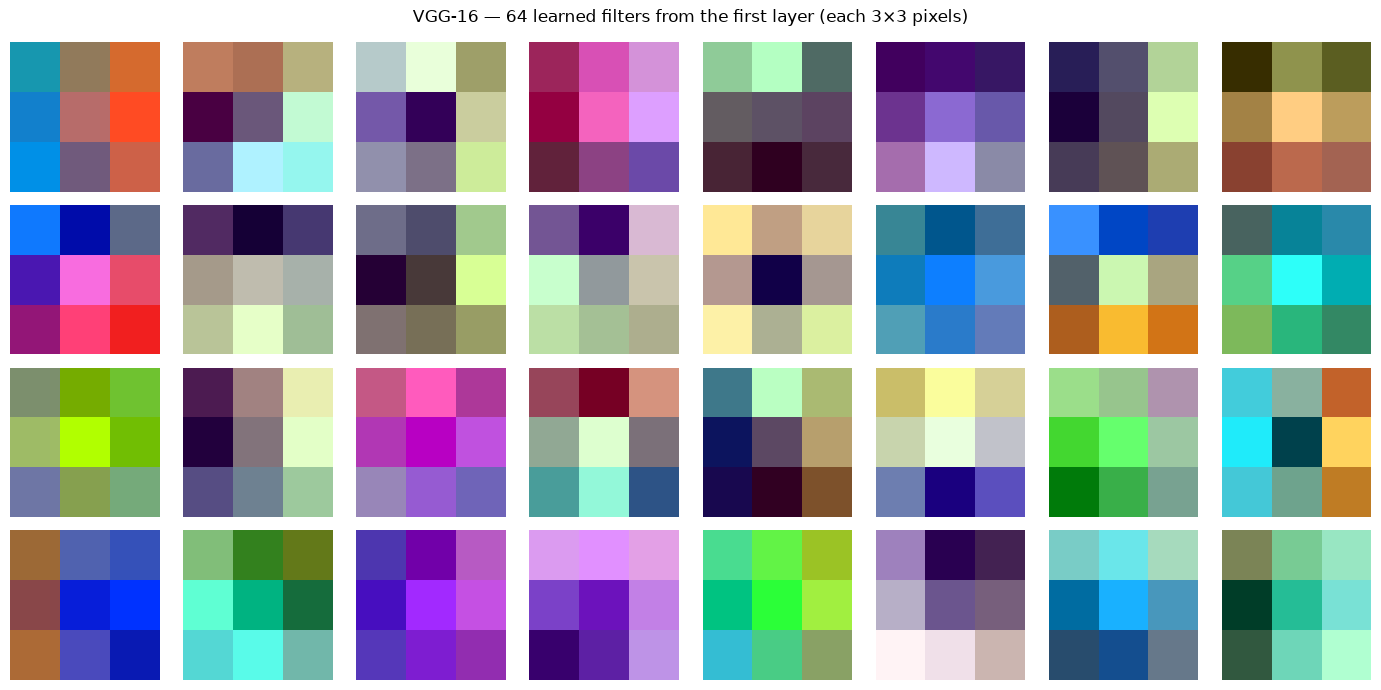

In [5]:
# Extract the weights of the very first layer — 64 filters, each 3×3 pixels.
# We normalise each filter to the 0–1 range just so the colours display cleanly.
# The permute() call simply reorders dimensions from PyTorch's format (C,H,W)
# to the format matplotlib expects for display (H,W,C).

import matplotlib.pyplot as plt

weights = vgg16.features[0].weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        f = weights[i].permute(1, 2, 0).numpy()
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        ax.imshow(f)
    ax.axis("off")

plt.suptitle("VGG-16 — 64 learned filters from the first layer (each 3×3 pixels)")
plt.tight_layout()
plt.show()

The above plot shows the VGG-16's first-layer filters. Each is only 3×3 pixels — too small to show dramatic patterns — but look closely and you can spot the building blocks: some filters have a bright side and a dark side (a simple edge detector), others are dominated by a single colour (a colour detector). They look like generic low-level primitives, not anything specific to steel or defects. 

That genericness is the whole reason feature extraction works. An edge or colour detector learned from ImageNet's cats and cars is just as useful for finding cracks in steel. We don't need to relearn these primitives — we can borrow them as-is. (For a clearer view of how these simple patterns build into textures and object parts at deeper layers, look back at Figure 1.)


### 2.4 Extracting Features 

We now apply the above procedure to a real-life input. To make the process tangible, we use a single photograph and observe the representation the frozen network produces for it. The cell below downloads the image and applies the standard preprocessing that every ImageNet-trained model expects: resizing, centre-cropping, and normalisation using ImageNet's channel statistics.

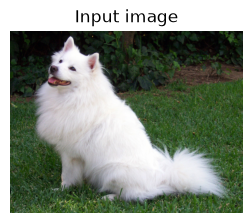

In [10]:
# Download a sample image and apply standard ImageNet preprocessing.
IMG_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

import requests
from PIL import Image
from io import BytesIO
import torchvision.transforms as transforms

response = requests.get(IMG_URL, timeout=10)
response.raise_for_status()

img = Image.open(BytesIO(response.content)).convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

input_tensor = preprocess(img).unsqueeze(0)  # shape: (1, 3, 224, 224)

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()

To see the network actually responding to an image, we visualise its feature maps — the activations produced at several layers as the dog image passes through. Reading from top to bottom, the maps progress from fine, edge-like responses in the early layers to coarser, more abstract responses in the deeper layers, where the network reacts to textures and object parts rather than raw pixels. This is the feature hierarchy of Section 1, made visible on a single image.

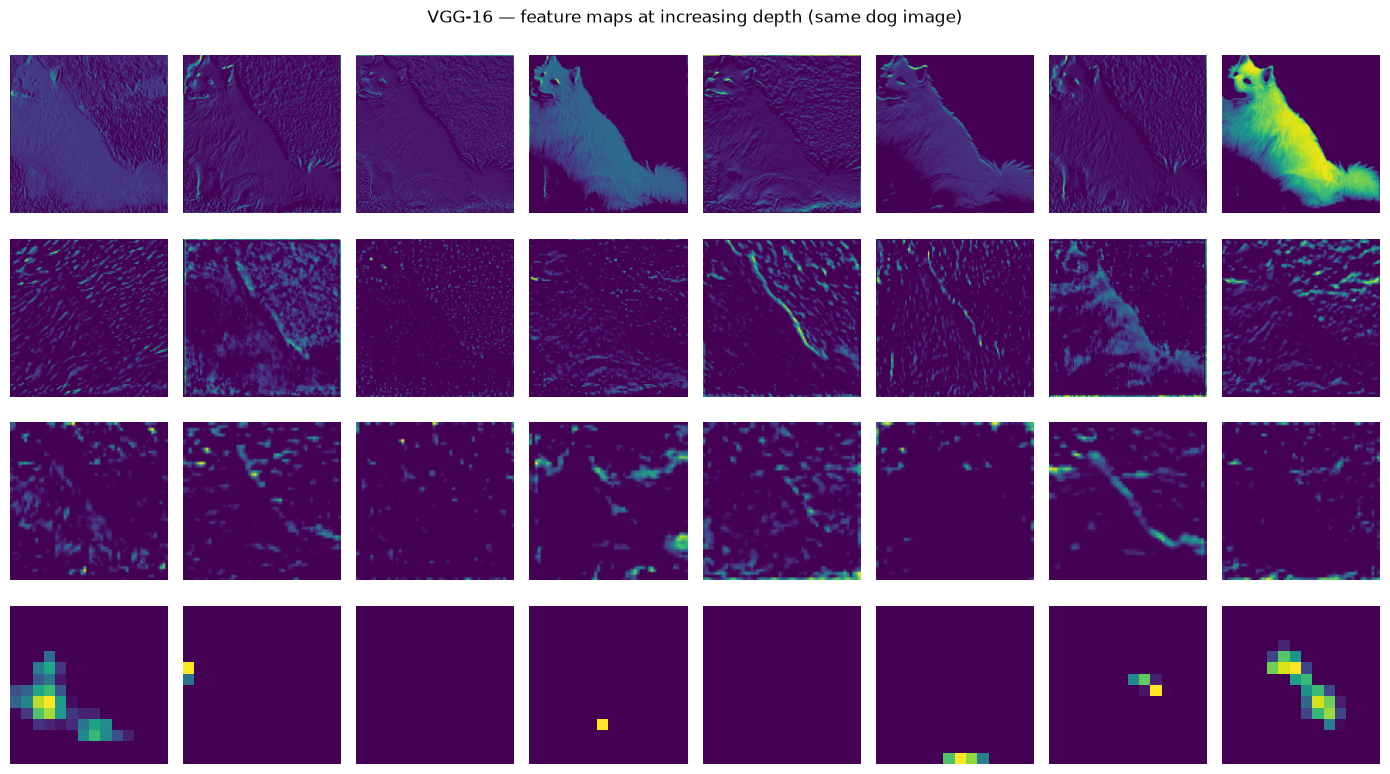

In [11]:
# Deeper filters cannot be rendered as colour images (they have hundreds of
# input channels). Instead we visualise their FEATURE MAPS: how individual
# channels respond to the dog image prepared earlier. Sampling several layers
# at increasing depth reveals the hierarchy — early layers respond to edges and
# colour, deeper layers to textures and object parts.

# Conv layers in VGG-16's feature stack, spanning shallow to deep.
STAGE_LAYERS = [0, 7, 14, 28]   # 64ch → 128ch → 256ch → 512ch

# Register hooks to capture each stage's activations in one forward pass.
activations = {}
handles = []
for idx in STAGE_LAYERS:
    handles.append(
        vgg16_backbone.features[idx].register_forward_hook(
            lambda m, i, o, idx=idx: activations.__setitem__(idx, o.detach())
        )
    )

with torch.no_grad():
    vgg16_backbone(input_tensor)   # reuses the dog image from the previous cell

for h in handles:
    h.remove()

# One row per stage; show the first 8 channels of each.
N_SHOW = 8
fig, axes = plt.subplots(len(STAGE_LAYERS), N_SHOW, figsize=(14, 2 * len(STAGE_LAYERS)))

for row, idx in enumerate(STAGE_LAYERS):
    feat = activations[idx][0].cpu()            # (channels, H, W)
    for col in range(N_SHOW):
        ax = axes[row, col]
        if col < feat.shape[0]:
            fmap = feat[col].numpy()
            fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
            ax.imshow(fmap, cmap="viridis")
        ax.axis("off")
    # Label each row with its layer index and channel count.
    axes[row, 0].set_ylabel(f"features[{idx}]\n({feat.shape[0]} ch)",
                            rotation=0, ha="right", va="center", fontsize=10)

plt.suptitle("VGG-16 — feature maps at increasing depth (same dog image)")
plt.tight_layout()
plt.show()

## 3. Transfer Learning

So far we have been locking all the pretrained weights and only training a new output layer on top. That works well when your dataset is small. But what if you have more data, and the pretrained features are not quite right for your task?

In that case, you can go one step further — you **unlock** some of the later layers and let them adjust during training. This is called **fine-tuning**. The early layers (which detect generic edges and textures) stay locked, but the deeper layers (which detect more task-specific patterns) are allowed to adapt.

> *A pretrained model is someone who already knows how to see. We are not teaching them to see again — we are just teaching them what to look for.*

The figure below shows both strategies side by side:

![](../episodes/Fig/03_Feature_extraction_vs_Fine_tuning.png)

*Figure 3 – Feature extraction (left) vs. fine-tuning (right). In fine-tuning, later layers of the backbone are allowed to update.*

Source: Zhang, A., Lipton, Z. C., Li, M., & Smola, A. J. (2023). Dive into Deep Learning. Cambridge University Press.

URL: https://d2l.ai/chapter_computer-vision/fine-tuning.html *

The frozen backbone is never updated — its weights stay fixed. This makes training extremely fast and stable even on small datasets.

| Strategy | Pretrained weights | New head | Works best when |
|---|---|---|---|
| **Feature extraction** | All locked | Trained | Dataset is small (< 1k images) |
| **Fine-tuning** | Later layers unlocked | Trained | Dataset is medium to large |

### Rule of thumb

```
Dataset size     →   Strategy
──────────────────────────────────────────
Small  (< 1k)    →   Feature extraction (lock everything)
Medium (1k–10k)  →   Fine-tune the last few layers
Large  (> 10k)   →   Fine-tune most or all layers
```

Now we'll put both strategies into a single reusable function. You don't need
to understand every line inside it — think of it as a tool you call by name.

The two things you control are:
- **which model** you want to use (`vgg16`, `resnet50`, or `vit_b_16`)
- **which strategy** you want (`feature_extraction` or `fine_tuning`)



## 4. VGG — Depth Through Simplicity

We have already been using VGG-16 as our example backbone — now let's understand what is actually inside it and why it was such a breakthrough.

VGGNet was introduced by Simonyan & Zisserman (2014) and won the ImageNet challenge by making a surprisingly simple argument: **depth matters more than complexity**. Previous networks used large filters (7×7, 11×11) to capture wide regions of the image. VGG replaced all of them with small 3×3 filters and just stacked more layers.

> Simonyan, K., & Zisserman, A. (2014). [**Very Deep Convolutional Networks for Large-Scale Image Recognition.** arXiv:1409.1556](https://arxiv.org/abs/1409.1556).

### 4.1 Design Philosophy

The entire VGG architecture is built by repeating one simple block:

```python
Conv2d(3×3, same padding) → ReLU  [×N] (Blue blocks in the following figure)
MaxPool2d(2×2, stride=2)  (Red blocks in the following figure)
```

Why 3×3? Two stacked 3×3 layers see the same region of the image as one 5×5
layer — but with fewer weights and an extra non-linearity in between, which
helps the network learn richer patterns. Five of these blocks are stacked in
sequence, each one doubling the number of filters as the spatial size shrinks.


Therefore, stacking small 3×3 filters achieves the **same receptive field** as a single large filter but with:
- **fewer parameters** (two 3×3 layers = 18 weights vs. one 5×5 = 25 weights per channel)
- **more non-linearities** → richer representations

The figure below shows the full VGG-16 layout — notice how the channel depth
(numbers on the right) doubles after each pooling step, while the spatial
dimensions shrink.

![](../episodes/Fig/03_VGG16_arch.png)

*Figure 4 – VGG-16 architecture: 13 convolutional + 3 fully-connected layers. Channel depth doubles after each pooling block.

Source: Very Deep Convolutional Networks (VGG) Essential Guide. URL: https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/*

### 4.2 Strengths and Limitations

| Strength | Limitation |
| :--: | :---: |
| Simple and predictable — easy to understand and modify | ~138 million parameters — large memory footprint |
| Features transfer well to other tasks | Three large fully-connected layers at the end are expensive |
| A reliable, well-understood baseline | Slower than more modern architectures |

The code below passes a dummy image through VGG-16 and prints the output
size at each step. You don't need to read the code line by line — focus on
the printed output when you run it.

Two things to watch for:
- The **spatial size** (the last two numbers) shrinks by half after each
  pooling step — from 224 down to 7
- The **number of channels** (the second number) doubles as we go deeper —
  from 64 up to 512

This is the core VGG pattern in action.

In [12]:
# Pass a dummy image through VGG-16 and print the output shape at each layer.
# We only print Conv and Pooling layers to keep the output readable —
# ReLU and BatchNorm layers don't change the shape so they are skipped.

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

print("VGG-16 — layer-by-layer output shapes (input: 1×3×224×224)")
print("=" * 60)

x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    for i, layer in enumerate(vgg16.features):
        x = layer(x)
        if isinstance(layer, (nn.Conv2d, nn.MaxPool2d)):
            print(f"  features[{i:2d}] {layer.__class__.__name__:12s}  → {tuple(x.shape)}")

    x = vgg16.avgpool(x)
    print(f"  avgpool                       → {tuple(x.shape)}")
    x = x.flatten(1)
    print(f"  flatten                       → {tuple(x.shape)}")

    for i, layer in enumerate(vgg16.classifier):
        x = layer(x)
        if isinstance(layer, nn.Linear):
            print(f"  classifier[{i}] Linear         → {tuple(x.shape)}")

total_params = sum(p.numel() for p in vgg16.parameters())
print(f"\nTotal parameters: {total_params:,}")

VGG-16 — layer-by-layer output shapes (input: 1×3×224×224)
  features[ 0] Conv2d        → (1, 64, 224, 224)
  features[ 2] Conv2d        → (1, 64, 224, 224)
  features[ 4] MaxPool2d     → (1, 64, 112, 112)
  features[ 5] Conv2d        → (1, 128, 112, 112)
  features[ 7] Conv2d        → (1, 128, 112, 112)
  features[ 9] MaxPool2d     → (1, 128, 56, 56)
  features[10] Conv2d        → (1, 256, 56, 56)
  features[12] Conv2d        → (1, 256, 56, 56)
  features[14] Conv2d        → (1, 256, 56, 56)
  features[16] MaxPool2d     → (1, 256, 28, 28)
  features[17] Conv2d        → (1, 512, 28, 28)
  features[19] Conv2d        → (1, 512, 28, 28)
  features[21] Conv2d        → (1, 512, 28, 28)
  features[23] MaxPool2d     → (1, 512, 14, 14)
  features[24] Conv2d        → (1, 512, 14, 14)
  features[26] Conv2d        → (1, 512, 14, 14)
  features[28] Conv2d        → (1, 512, 14, 14)
  features[30] MaxPool2d     → (1, 512, 7, 7)
  avgpool                       → (1, 512, 7, 7)
  flatten              

### 4.3 Building a new classification layer

Now we apply what we just saw. The final layer of VGG-16 outputs 1000 scores
— one for each ImageNet class. However, for our steel dataset (which will be used in the practical session), we have 6 defect classes, so we swap that layer out for a fresh one with 6 outputs, and lock everything else.
Run the cell below and check the printed classifier — the last line should
now read `Linear(in_features=4096, out_features=6)` instead of 1000. That
single change is all it takes to redirect the entire network toward our task.


In [13]:
# The final layer of VGG-16 outputs 1000 scores — one for each ImageNet class.

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# ── Freeze all layers ─────────────────────────────────────────────────────────
for param in vgg16.parameters():
    param.requires_grad = False

# ── Swap the last layer: 1000 classes → 6 defect classes ─────────────────────
vgg16.classifier[-1] = nn.Linear(4096, 6)
# ─────────────────────────────────────────────────────────────────────────────

# Confirm the change — last line should read Linear(in_features=4096, out_features=6)
print(vgg16.classifier)

total_params  = sum(p.numel() for p in vgg16.parameters())
trainable     = sum(p.numel() for p in vgg16.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")



Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=6, bias=True)
)

Total parameters:     134,285,126
Trainable parameters: 24,582


## 5. ResNet — Residual Connections and Deep Networks

VGG showed that depth improves performance — so why not just keep adding
layers? Researchers tried exactly that, and ran into a puzzling problem.

### 5.1 The Degradation Problem (vanishing gradients)

As networks get very deep (beyond ~20 layers), something unexpected happens:
performance starts to get *worse* — even on the training data itself. This is
not the model memorising noise (overfitting). The model is genuinely
struggling to learn.

The root cause is how networks learn. During training, each layer adjusts its
weights based on a signal passed backward from the output — called a
**gradient**. In a very deep network, this signal has to travel through
dozens of layers to reach the early ones. By the time it gets there, it has
become so weak that the early layers barely update at all. The network
effectively stops learning in its early stages.

He et al. (2016) called this the **degradation problem** (vanishing gradients) and proposed an
elegantly simple fix — which we cover next.

> [He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning
> for Image Recognition.* CVPR. arXiv:1512.03385](https://arxiv.org/abs/1512.03385)


### 5.2 The Fix — Skip Connections

Here's solution was to add a **shortcut or a skip connection*** — (residual connection) that bypasses one or more layers:

$$\mathbf{y} = \mathcal{F}(\mathbf{x}, \{W_i\}) + \mathbf{x}$$

Instead of learning the full mapping $\mathcal{H}(\mathbf{x})$, the network only needs to learn the **residual** $\mathcal{F}(\mathbf{x}) = \mathcal{H}(\mathbf{x}) - \mathbf{x}$.

If the optimal mapping is close to an identity, residual learning makes this easy to achieve — the weights can simply be pushed toward zero..

The figure below shows this clearly — the curved arrow is the shortcut:

![](../episodes/Fig/03_Residual_block.png)


*Figure 5 – Residual block. The identity shortcut (dashed arrow) adds the input directly to the output of the two-layer stack.
 Source: [He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual Learning for Image Recognition. ](https://arxiv.org/pdf/1512.03385)*


In practice, ResNet employs two main types of residual blocks depending on the network architecture and 
dimensional requirements. The Identity block uses a direct shortcut connection when the input and output 
dimensions are the same — the input is added to the output as-is. However, when a block changes the number 
of channels or the spatial size, a direct addition is no longer possible since the shapes do not match. 
This is where the Convolutional (or Bottleneck) block comes in: it applies a 1×1 convolution or anyother required size, on the shortcut 
path purely to reshape the input to match the output dimensions, making the residual addition valid. 
Figure 6 illustrates both types of residual blocks, with the curved arrows representing the shortcut connections.

![](../episodes/Fig/03_skip_connection_types.png)

*Figure 6 illustrates two types of skip connections: the Identity block (left) and the Bottleneck/Convolutional block (right). The primary distinction between them lies in how the residual connection is processed. In the Identity block, the residual is added directly to the output without any modification. In contrast, the Bottleneck/Convolutional block applies a convolution operation followed by batch normalisation to the residual before it is combined with the output. Source: [ How to Code Your ResNet from Scratch in Tensorflow?](https://www.analyticsvidhya.com/blog/2021/08/how-to-code-your-resnet-from-scratch-in-tensorflow/)*

In [14]:
# A single residual block — the core repeating unit of ResNet.
# The key line is: out = self.relu(out + identity)
# This adds the original input back to the output before the final activation.
# The shortcut layer only activates when the input and output sizes differ —
# in that case a 1×1 conv is used to match the dimensions before adding.

class ResidualBlock(nn.Module):
    """
    Basic residual block as in He et al. (2016).
    Two 3×3 Conv layers with a skip connection.
    A 1×1 projection is added when dimensions change.
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)              # carry input through the shortcut
        out = self.relu(self.bn1(self.conv1(x))) # first conv + stabilise + activate
        out = self.bn2(self.conv2(out))          # second conv + stabilise
        out = self.relu(out + identity)          # add shortcut back, then activate
        return out

# ── Show what happens to activations ─────────────────────────────────────────
block = ResidualBlock(in_channels=64, out_channels=64)
x_in  = torch.randn(1, 64, 56, 56)
x_out = block(x_in)

print(f"Input  : {tuple(x_in.shape)}")
print(f"Output : {tuple(x_out.shape)}  ← same spatial size and channels")
print(f"Block parameters: {sum(p.numel() for p in block.parameters()):,}")


Input  : (1, 64, 56, 56)
Output : (1, 64, 56, 56)  ← same spatial size and channels
Block parameters: 73,984


### 5.3 Why Skip Connections Work

Now that you've seen the residual block, here is what that small addition
actually achieves:

- **Gradients flow more easily**: the shortcut gives the training signal a
  direct path backward through the network, so early layers actually update
- **Much deeper networks become trainable**: ResNet-50, ResNet-101, and
  ResNet-152 all train stably — something impossible with plain stacking
- **The network has a safety net**: if a layer learns nothing useful, the
  shortcut ensures the input passes through unchanged — the network can't
  get worse by adding a layer

### 5.4 ResNet Architecture

The figure below puts everything together. It compares three networks
side by side — VGG-19, a plain 34-layer network, and a 34-layer residual
network.

The curved arrows on the right column are the skip connections. Notice
that the dotted arrows appear where the number of channels increases —
those are the 1×1 projection shortcuts we built in the code above.

Compare the plain network (middle) and the residual network (right) —
they have the exact same layers, but the skip connections are what make
the residual version actually trainable at that depth.

![](../episodes/Fig/03_ResNet_arch.png)


*Figure 7 — ResNet architecture compared to VGG-19 and a plain deep network.
Left: VGG-19 (19.6B FLOPs). Middle: plain 34-layer network. Right: Actual ResNet 34-layer
residual network with skip connections — the dotted arrows indicate projections
where channel dimensions increase. Source: He et al. (2016),
[Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)*

### 5.5 ResNet-50 (Popular version)

The figure above showed ResNet-34 — one of the smaller variants in the ResNet family. There is an even lighter version, ResNet-18, useful for quick experiments and commonly used as a baseline or benchmark in research. In practice, **ResNet-50** is the most commonly used version for transfer learning. It follows the same residual block idea but uses deeper blocks internally, giving it a richer 2048-dimensional feature vector at the end.

Unlike VGG's three large fully-connected layers, ResNet ends with a single
**global average pooling** step — it takes the entire spatial output and
averages it down to one number per channel. This is much more efficient and
is one reason ResNet transfers better to new tasks.

Run the cell below and compare the shapes to what you saw in VGG-16 — notice
how the network reaches a much more compact representation by the end.

In [15]:
# Pass a dummy image through each stage of ResNet-50 and print the output shape.
# Each "layer" here is a group of residual blocks — not a single layer.
# The final flatten produces a 2048-dim feature vector — this is what gets
# passed to the new classification head during transfer learning.

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

print("ResNet-50 — layer-by-layer output shapes (input: 1×3×224×224)")
print("=" * 60)

x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    layers = {
        "conv1"        : resnet50.conv1,
        "bn1+relu+pool": nn.Sequential(resnet50.bn1, resnet50.relu, resnet50.maxpool),
        "layer1"       : resnet50.layer1,
        "layer2"       : resnet50.layer2,
        "layer3"       : resnet50.layer3,
        "layer4"       : resnet50.layer4,
        "avgpool"      : resnet50.avgpool,
    }
    for name, stage in layers.items():
        x = stage(x)
        print(f"  {name:20s} → {tuple(x.shape)}")
    x = x.flatten(1)
    print(f"  {'flatten':20s} → {tuple(x.shape)}  ← 2048-dim feature vector")

print(f"\nTotal parameters: {sum(p.numel() for p in resnet50.parameters()):,}")

ResNet-50 — layer-by-layer output shapes (input: 1×3×224×224)
  conv1                → (1, 64, 112, 112)
  bn1+relu+pool        → (1, 64, 56, 56)
  layer1               → (1, 256, 56, 56)
  layer2               → (1, 512, 28, 28)
  layer3               → (1, 1024, 14, 14)
  layer4               → (1, 2048, 7, 7)
  avgpool              → (1, 2048, 1, 1)
  flatten              → (1, 2048)  ← 2048-dim feature vector

Total parameters: 25,557,032


### 5.6 Demonstrate the Benefit of Skip Connections: Gradient Norm Comparison

We said that skip connections help gradients reach the early layers. Let's see this concretely.

The cell below measures the **gradient norm** in the early layers after one training step — 
think of it as measuring how strong the learning signal is at the start of the network. 
A healthy gradient norm sits somewhere between 1 and 1000. If it collapses toward zero, 
the early layers stop learning entirely — this is the **vanishing gradient problem** that 
plagued deep networks before ResNet.

We measure this across three networks we have already seen: VGG-16, a plain deep network 
with no skip connections, and ResNet-50. Run the cell and compare the three numbers.

In [17]:
# Measure how strong the learning signal (gradient) is in ResNet-50's early
# layers after a single backward pass. We use random weights (no pretraining)
# to simulate what happens at the start of training from scratch.
# A non-zero value confirms gradients are reaching the early layers —
# something a plain deep network without skip connections struggles to achieve.

import copy
import numpy as np
torch.manual_seed(42)

def gradient_norm_through_depth(model, depth_layers):
    """Return average gradient norm in early layers after one backward pass."""
    model.train()
    x    = torch.randn(2, 3, 224, 224)
    out  = model(x)
    loss = out.mean()
    loss.backward()
    norms = [p.grad.norm().item()
             for p in list(model.parameters())[:depth_layers]
             if p.grad is not None]
    return np.mean(norms) if norms else 0.0

# VGG-16 with random weights
vgg_model                = models.vgg16(weights=None)
vgg_model.classifier[6]  = nn.Linear(4096, 2)

# ResNet-50 with random weights
resnet_model    = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(2048, 2)

# Plain network: flatten gives 3×224×224 = 150528, use that as input size
plain_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(150528, 2048), nn.ReLU(),
    *[nn.Sequential(nn.Linear(2048, 2048), nn.ReLU()) for _ in range(47)],
    nn.Linear(2048, 2)
)

vgg_norm    = gradient_norm_through_depth(vgg_model,    depth_layers=5)
plain_norm  = gradient_norm_through_depth(plain_model,  depth_layers=5)
resnet_norm = gradient_norm_through_depth(resnet_model, depth_layers=5)

print(f"VGG-16         — mean gradient norm in first 5 layers: {vgg_norm:.6f}")
print(f"Plain network  — mean gradient norm in first 5 layers: {plain_norm:.6f}")
print(f"ResNet-50      — mean gradient norm in first 5 layers: {resnet_norm:.6f}")
print()
print(f"ResNet gradient is {resnet_norm / (vgg_norm   + 1e-8):.1f}x stronger than VGG-16.")
print(f"ResNet gradient is {resnet_norm / (plain_norm + 1e-8):.1f}x stronger than the plain network.")
print()
#print("Key point: skip connections maintain non-trivial gradient flow even at depth.")
#print("Without them, these values drop toward zero and early layers stop updating.")

VGG-16         — mean gradient norm in first 5 layers: 0.541485
Plain network  — mean gradient norm in first 5 layers: 0.000000
ResNet-50      — mean gradient norm in first 5 layers: 49.153959

ResNet gradient is 90.8x stronger than VGG-16.
ResNet gradient is 4915395869.6x stronger than the plain network.



The numbers above confirm exactly what we expected. The plain network scores zero — the  gradient has completely vanished by the time it reaches the early layers, meaning those layers receive no learning signal at all. VGG-16 survives with a small but non-zero value (0.54) only because it is relatively shallow at 16 layers — push it deeper and it would face the same fate. ResNet-50, despite being 50 layers deep, maintains a strong gradient of 49.15 thanks to its skip connections acting as gradient highways. This single comparison captures why ResNet was a turning point — depth alone breaks networks, but depth with skip connections makes them stronger.

## 6. Vision Transformer (ViT) — Attention Over Patches

So far, both VGG and ResNet process images the same way at heart — a small
filter slides across the image one local region at a time. Skip connections
solved the vanishing gradient problem and let us go deeper, but the
fundamental operation never changed: every layer still only sees a small
neighbourhood of pixels. To understand global structure, information has to
travel gradually through many layers before the network sees the full picture.

This raises a natural question: what if the network could look at the entire
image at once, right from the first layer? That is exactly the idea behind
the **Vision Transformer**. Instead of sliding a filter across pixels, it
splits the image into a fixed set of patches, treats each patch like a word
in a sentence, and uses self-attention to let every patch directly
communicate with every other patch — in a single step. For steel defect
classification, this matters: a scratch that spans the full surface, or a
rolled-in scale with irregular spread, can be connected globally from layer
one — something CNNs can only do gradually.

> Dosovitskiy, A., et al. (2020). [*An Image is Worth 16×16 Words:
> Transformers for Image Recognition at Scale.*
> arXiv:2010.11929](https://arxiv.org/abs/2010.11929).

### 6.1 From Pixels to Patches

Instead of sliding a filter across the image, ViT cuts the image into a
grid of fixed-size **patches** and treats them like a sequence of words
in a sentence. Each patch becomes one "token" — a flat vector that
represents that region of the image.

$$\text{Image } (H \times W \times C) \longrightarrow N \text{ patches of size } P \times P$$

$$N = \frac{H \times W}{P^2}$$

For a 224×224 image with patch size $P = 16$: $N = 196$ patches —
so the image becomes a sequence of 196 tokens, each covering a 16×16
pixel region. Each patch is then:
1. Flattened to a vector of length $P^2 \cdot C$
2. Linearly projected to a fixed embedding dimension $D$
3. Combined with a **positional embedding** so the model knows patch location

A learnable **[CLS] token** is prepended; its final representation is used
for classification.

![](../episodes/Fig/03_Vision_transformer.png)

*Figure 8: Vision Transformer (ViT) architecture. The image is split into patches, each embedded as a vector and combined with a positional marker. The full sequence is processed by a Transformer encoder; the (CLS) token's final state is used for classification. Source: Dosovitskiy, A., et al. (2020), [An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale. arXiv:2010.11929](https://arxiv.org/abs/2010.11929)*


### 6.2 How the Patches Talk to Each Other — Self-Attention

Once the image is broken into several patch tokens, the next question is:
how does the network figure out which patches are relevant to each other?

In a CNN, each layer only looks at its immediate neighbours. ViT does
something much more powerful — every patch looks at every other patch
simultaneously and decides how much to "pay attention" to each one. This
is called **self-attention**.

For steel defects: the patch containing the tip of a scratch should pay
high attention to the patch containing its tail — even if they are on
opposite sides of the image. A CNN would only connect them after many
layers. ViT connects them from the very first step.

The attention score between any two patches is computed as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

**Q**, **K**, and **V** stand for ***Query***, ***Key***, and ***Value*** — a way of asking "how
relevant is this patch to that one?" You don't need to memorise the
formula; the key takeaway is that **every patch can directly influence
every other patch from layer one** — something CNNs only achieve at their
deepest layers.

The figure below shows real attention maps from a trained ViT — the
bright regions are what the model focuses on when classifying each image:

![](../episodes/Fig/03_Attention_maps.png)

*Figure 9:  Attention maps: the model learns to attend to semantically relevant image regions without any supervision on location. Illustration of different attention mechanisms, i.e., softmax attention, linear attention, and enhanced linear attention. The first row is the original input images. Enhanced linear attention can substantially eliminate some irrelevant distractions and focus better on the object itself, such as the objects in the fifth and last columns. Source: [Zheng (2025), The Linear Attention Resurrection in Vision Transformer](https://arxiv.org/pdf/2501.16182)*

### 6.3 Building the Patch Embedding

Let's implement the first step of ViT — turning an image into a sequence
of patch tokens.

Each 16×16 patch is flattened into a vector and then passed through a
single linear layer that projects it to a fixed size of 768 numbers. This
768-dimensional vector is the "embedding" — the representation the
Transformer will work with.

A neat trick from the original paper: instead of manually cutting the
image into patches and then projecting each one, a single Conv2d layer
with kernel size 16 and stride 16 does both operations in one step — it
naturally lands on non-overlapping 16×16 regions.

You don't need to follow every line below — focus on the printed output
when you run it. It will confirm that a 224×224 image becomes exactly
196 tokens of 768 dimensions each.

In [18]:
# Implement patch embedding — the first step of ViT.
# A Conv2d with kernel=stride=patch_size cuts the image into non-overlapping
# patches and projects each one to embed_dim dimensions in a single operation.
# The flatten and transpose at the end reorder dimensions so the output is
# (batch, num_patches, embed_dim) — the format the Transformer expects.

class PatchEmbedding(nn.Module):
    """
    Splits a (B, C, H, W) image into N non-overlapping patches
    and projects each patch to a D-dimensional embedding.

    As in Dosovitskiy et al. (2020): a single Conv2d with kernel=stride=P
    efficiently performs both the split and the linear projection.
    """
    def __init__(self, img_size: int = 224, patch_size: int = 16,
                 in_channels: int = 3, embed_dim: int = 768):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size  = patch_size
        self.embed_dim   = embed_dim
        # One Conv2d replaces flatten + linear projection
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):                           # x: (B, C, H, W)
        x = self.proj(x)                            # → (B, D, H/P, W/P)
        x = x.flatten(2)                            # → (B, D, N)
        x = x.transpose(1, 2)                       # → (B, N, D)
        return x


# ── Test ──────────────────────────────────────────────────────────────────────
patch_emb = PatchEmbedding(img_size=224, patch_size=16, in_channels=3, embed_dim=768)
x = torch.randn(1, 3, 224, 224)
patches = patch_emb(x)

print(f"Input image shape   : {tuple(x.shape)}")
print(f"Patch embedding out : {tuple(patches.shape)}")
print(f"  → {patches.shape[1]} patches, each a {patches.shape[2]}-dim vector")
print()
print(f"Each patch covers a {16}×{16}={16*16} pixel region of the image,")
print(f"projected to a {768}-dim embedding (same as BERT-base).")


Input image shape   : (1, 3, 224, 224)
Patch embedding out : (1, 196, 768)
  → 196 patches, each a 768-dim vector

Each patch covers a 16×16=256 pixel region of the image,
projected to a 768-dim embedding (same as BERT-base).


### 6.4 Vision Transformer — Built from Scratch

We have already built `PatchEmbedding` above. Now let's assemble the full ViT from scratch so every component is visible — rather than loading a pretrained black box.

The three ingredients we need:

**PatchEmbedding** — already done in 6.3.

**TransformerBlock** — wraps multi-head self-attention with an MLP,
LayerNorm on both, and residual connections around each. This is the
repeating unit of the encoder.

**VisionTransformer** — stacks N TransformerBlocks and adds a
classification head at the end. We use global average pooling over all
patch tokens instead of a [CLS] token — simpler, and sufficient for
our purposes.

In [20]:
# Transformer Block: the repeating unit inside the ViT encoder.
# Each block applies multi-head self-attention followed by a small MLP,
# with LayerNorm and a residual connection wrapping each operation.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TransformerBlock(nn.Module):
    """Transformer block with multi-head attention and MLP"""
    def __init__(self, embed_dim=128, num_heads=4, mlp_dim=256, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.attention  = nn.MultiheadAttention(embed_dim, num_heads,
                                                 dropout=dropout_rate,
                                                 batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout_rate),
        )
        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.dropout    = nn.Dropout(dropout_rate)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        attn_output = self.dropout(attn_output)
        x = self.layernorm1(x + attn_output)   # residual + norm
        mlp_output = self.mlp(x)
        x = self.layernorm2(x + mlp_output)    # residual + norm
        return x
    
# Assemble the full Vision Transformer.
# patch_embed → positional embeddings → N TransformerBlocks →
# LayerNorm → global average pool → classification head

class VisionTransformer(nn.Module):
    """Vision Transformer model for image classification (trained from scratch)"""
    def __init__(self, input_size, num_classes, patch_size=16, num_layers=4,
                 num_heads=4, embed_dim=128, mlp_dim=256, dropout_rate=0.1):
        super(VisionTransformer, self).__init__()
        self.patch_embed = PatchEmbedding(
            img_size=input_size,      # ← match the existing class signature
            patch_size=patch_size,
            in_channels=3,
            embed_dim=embed_dim
        )
        num_patches = (input_size // patch_size) ** 2
        self.pos_embedding = nn.Embedding(num_patches, embed_dim)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout_rate)
            for _ in range(num_layers)
        ])
        self.norm    = nn.LayerNorm(embed_dim, eps=1e-6)
        self.dropout = nn.Dropout(dropout_rate)
        self.head    = nn.Linear(embed_dim, num_classes)
        self.num_patches = num_patches

    def forward(self, x):
        x = self.patch_embed(x)
        positions = torch.arange(self.num_patches, device=x.device)
        x = x + self.pos_embedding(positions)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        x = self.head(x)
        return x

# Build the ViT model from scratch
print("Building Vision Transformer Model (from scratch)...")
vit_scratch = VisionTransformer(
    input_size=224,
    num_classes=6,
    patch_size=16,
    num_layers=4,
    num_heads=4,
    embed_dim=128,
    mlp_dim=256,
    dropout_rate=0.1
).to(device)

optimizer_vit = torch.optim.Adam(vit_scratch.parameters(), lr=0.001)

trainable = sum(p.numel() for p in vit_scratch.parameters() if p.requires_grad)
total     = sum(p.numel() for p in vit_scratch.parameters())
print("\nVision Transformer Model (from scratch)")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")

Building Vision Transformer Model (from scratch)...

Vision Transformer Model (from scratch)
Total parameters:     654,470
Trainable parameters: 654,470


In [21]:
# Quick shape sanity check — confirm the model accepts a real image batch
dummy = torch.randn(2, 3, 224, 224).to(device)
out   = vit_scratch(dummy)

print(f"Input shape:  {tuple(dummy.shape)}  ← (batch, channels, height, width)")
print(f"Output shape: {tuple(out.shape)}   ← (batch, num_classes) = (2, 6)")
print("\nModel is ready for training.")

Input shape:  (2, 3, 224, 224)  ← (batch, channels, height, width)
Output shape: (2, 6)   ← (batch, num_classes) = (2, 6)

Model is ready for training.


### 6.5 Why Multiple Attention Heads?

In section 6.2 we saw the core attention formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

That is a single attention operation — one set of Q, K, V projections
scanning for one type of relationship between patches. But a defect image
has many kinds of relationships simultaneously: a scratch has spatial
continuity, a patch defect has texture, an inclusion has contrast against
background. A single attention head is unlikely to capture all of these at
once.

**Multi-head attention** runs $h$ independent attention operations in
parallel, each learning to look for a different relationship:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \, W^O$$

where each head is:

$$\text{head}_i = \text{Attention}(Q W_i^Q,\ K W_i^K,\ V W_i^V)$$

In our scratch model we set `num_heads=4` and `embed_dim=128`, so each
head works on a $128 / 4 = 32$-dimensional subspace of the embedding.
The four heads compute attention independently, then their outputs are
concatenated back to 128 dimensions and passed through a linear layer
$W^O$ to mix the information across heads.

**Why split into subspaces rather than running full 128-dim attention
four times?** Two reasons: computational cost grows quadratically with
dimension, and splitting forces each head to specialise — head 1 might
learn positional proximity, head 2 might learn texture similarity, and
so on, rather than all four learning the same thing.

In ViT-B/16 (the full pretrained model we loaded in section 6.4),
`num_heads=12` and `embed_dim=768`, giving each head a 64-dimensional
subspace — the same ratio, just at a larger scale.

### 6.6 ViT-B/16 — The Pretrained Model

The scratch model above is lightweight (4 layers, 128-dim). In practice,
**ViT-B/16** is the standard pretrained variant:
- **B** = Base — medium-sized (also Small and Large exist)
- **16** = patch size of 16×16, giving 196 patches for a 224×224 image
- **86M parameters**, all in the encoder — unlike VGG where 90% sat in
  the FC layers, here every parameter does attention or MLP work

Like ResNet, ViT needs pretraining on large data (ImageNet) to learn
meaningful patch relationships — without it, ViT typically underperforms
CNNs on small datasets. This is why we load ImageNet weights here.

The printed output shows three top-level components:
- `conv_proj` — the patch embedding we built in 6.3
- `encoder` — 12 Transformer blocks where self-attention happens
- `heads` — the classification layer we replace, just like VGG's
  `classifier` and ResNet's `fc`

In [22]:
# Load pretrained ViT-B/16 and print its top-level structure.
# We then print the first Transformer encoder block in detail —
# this shows the self-attention and MLP layers inside each block.
# Note: the 'heads' component at the end is what we replace for
# transfer learning, just like VGG's classifier and ResNet's fc layer.

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

print("ViT-B/16 top-level structure:")
for name, module in vit.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name:20s}  {n_params:>12,} params")

print()
total = sum(p.numel() for p in vit.parameters())
print(f"Total parameters: {total:,}")
print()
print("Encoder detail — first Transformer block:")
print(vit.encoder.layers[0])


ViT-B/16 top-level structure:
  conv_proj                  590,592 params
  encoder                 85,207,296 params
  heads                      769,000 params

Total parameters: 86,567,656

Encoder detail — first Transformer block:
EncoderBlock(
  (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): MLPBlock(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): Dropout(p=0.0, inplace=False)
  )
)


### 6.7 Tracing the Input Through ViT

Before the patches reach the Transformer encoder, three things happen:
1. Each patch is embedded into a 768-dim vector (what we built above)
2. The [CLS] token is added at the front of the sequence
3. A **positional embedding** is added to every token — this tells the
   model where each patch came from in the original image, since the
   Transformer itself has no sense of order or position

The cell below traces this pipeline manually so you can see the exact
sequence shape that enters the encoder. The key number to notice is
**197** — 196 patches plus 1 [CLS] token.

In [23]:
# Visualise self-attention weights on a sample image
# We'll register a hook on the last encoder block to capture attention matrices

attention_weights = {}

def save_attention_hook(module, input, output):
    # output from MultiheadAttention is (attn_output, attn_weights)
    # but torchvision's ViT uses a custom EncoderBlock; we capture via the
    # self_attention sub-module which returns (x, attn_weight)
    pass  # see below

# Trace the ViT input pipeline step by step:
#   1. Embed the image patches (conv_proj)
#   2. Prepend the [CLS] token
#   3. Add positional embeddings so the model knows patch locations
# The result is the sequence that enters the first Transformer encoder block.

vit.eval()
x_img = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    # Step 1 — patch embedding
    x_patches = vit._process_input(x_img)

    # Step 2 — prepend the [CLS] token
    batch_class_token = vit.class_token.expand(x_patches.shape[0], -1, -1)
    x_full = torch.cat([batch_class_token, x_patches], dim=1)

    # Step 3 — add positional embedding
    x_pos = x_full + vit.encoder.pos_embedding

print(f"After patch embedding : {tuple(x_patches.shape)}")
print(f"After adding [CLS]    : {tuple(x_full.shape)}")
print(f"After positional emb  : {tuple(x_pos.shape)}")
print()
print(f"→ {x_pos.shape[1]} tokens enter the encoder: "
      f"1 [CLS] + {x_patches.shape[1]} patches, each {x_pos.shape[2]}-dim")


After patch embedding : (1, 196, 768)
After adding [CLS]    : (1, 197, 768)
After positional emb  : (1, 197, 768)

→ 197 tokens enter the encoder: 1 [CLS] + 196 patches, each 768-dim


## 7. Architectural Comparison

We have now worked through all three architectures hands-on. Before
deciding which one to use for a given problem, it helps to see them
side by side — not just in terms of accuracy, but in terms of size,
speed, and what kind of features they produce.

The two cells below compare:
- **Parameter count** — how many weights each model has and how much
  memory it needs
- **Core properties** — how each model processes images, what assumptions
  it makes, and when it works best

As you read through the comparison, think about the dataset
you just want to work with or the dataset that we will use in the practical session— which model would you reach for first, and why?

### 7.1 Parameter Count

The table below loads all three models and counts their total parameters.
We use `weights=None` here — random weights — because we only care about
the architecture size, not the pretrained values.

The **Feature Dim** column shows the size of the feature vector each
model produces before the final classification layer — this is the
representation that gets passed to the new head during transfer learning.
A larger feature vector is not necessarily better; what matters is how
well those features describe the images in your specific task.

In [24]:
# Compare all three architectures across key metrics
# Load all three architectures without pretrained weights — we only need
# the model structure to count parameters, not the trained values.
# Feature Dim = size of the vector produced just before the output layer,
# i.e. what the new classification head receives as input.

architectures = {
    "VGG-16"    : models.vgg16(weights=None),
    "ResNet-50" : models.resnet50(weights=None),
    "ViT-B/16"  : models.vit_b_16(weights=None),
}

print(f"{'Architecture':<15} {'Total Params':>15} {'Input Size':>12} {'Feature Dim':>12}")
print("─" * 58)

feature_dims = {"VGG-16": 4096, "ResNet-50": 2048, "ViT-B/16": 768}
for name, model in architectures.items():
    total = sum(p.numel() for p in model.parameters())
    print(f"{name:<15} {total:>15,} {'224×224':>12} {feature_dims[name]:>12}")


Architecture       Total Params   Input Size  Feature Dim
──────────────────────────────────────────────────────────
VGG-16              138,357,544      224×224         4096
ResNet-50            25,557,032      224×224         2048
ViT-B/16             86,567,656      224×224          768


In [25]:
# A reusable function that prepares any of our three models for transfer learning.
# It handles three things automatically:
#   1. Loads the pretrained model with ImageNet weights
#   2. Replaces the final output layer with one sized for your dataset's classes
#   3. Locks or unlocks weights depending on the chosen strategy
#
# After calling it, check the printed summary — "Trainable params" tells you
# exactly how much of the model will actually update during training.
def build_transfer_model(
    backbone_name: str,
    num_classes: int,
    strategy: str = "feature_extraction",  # or "fine_tuning"
    unfreeze_from_layer: int = -1           # fine-tuning only: unfreeze last N layers
) -> nn.Module:
    """
    Returns a model ready for transfer learning.

    backbone_name : 'vgg16' | 'resnet50' | 'vit_b_16'
    num_classes   : number of target classes
    strategy      : 'feature_extraction' → freeze all backbone weights
                    'fine_tuning'        → unfreeze last `unfreeze_from_layer` layers
    """
    if backbone_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)
        params_to_check = list(model.features.parameters())

    elif backbone_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        params_to_check = list(model.parameters())[:-2]

    elif backbone_name == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)
        params_to_check = list(model.parameters())[:-2]

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    # Apply strategy
    if strategy == "feature_extraction":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.parameters():
            if param.shape[0] == num_classes:
                param.requires_grad = True

    elif strategy == "fine_tuning" and unfreeze_from_layer > 0:
        all_params = list(model.parameters())
        for param in all_params[:-unfreeze_from_layer]:
            param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    frozen    = total - trainable

    return model, total, trainable, frozen


# Collect results
rows = []
configs = [
    ("vgg16",     "feature_extraction", -1),
    ("vgg16",     "fine_tuning",        20),
    ("resnet50",  "feature_extraction", -1),
    ("resnet50",  "fine_tuning",        20),
    ("vit_b_16",  "feature_extraction", -1),
    ("vit_b_16",  "fine_tuning",        20),
]

for backbone, strategy, unfreeze in configs:
    _, total, trainable, frozen = build_transfer_model(
        backbone, num_classes=6, strategy=strategy, unfreeze_from_layer=unfreeze
    )
    label = "Feature Extraction" if strategy == "feature_extraction" else "Fine-Tuning (last 20)"
    rows.append((backbone, label, total, trainable, frozen))

# Print table
SEP  = "─" * 80
HEAD = f"{'Model':<12}  {'Strategy':<22}  {'Total':>12}  {'Trainable':>12}  {'Frozen':>12}"
print(SEP)
print(HEAD)
print(SEP)
for backbone, label, total, trainable, frozen in rows:
    print(f"{backbone:<12}  {label:<22}  {total:>12,}  "
          f"{trainable:>10,} ({100 * trainable / total:4.1f}%)  "
          f"{frozen:>10,} ({100 * frozen / total:4.1f}%)")
print(SEP)

────────────────────────────────────────────────────────────────────────────────
Model         Strategy                       Total     Trainable        Frozen
────────────────────────────────────────────────────────────────────────────────
vgg16         Feature Extraction       134,285,126      24,582 ( 0.0%)  134,260,544 (100.0%)
vgg16         Fine-Tuning (last 20)    134,285,126  133,139,718 (99.1%)   1,145,408 ( 0.9%)
resnet50      Feature Extraction        23,520,326      12,294 ( 0.1%)  23,508,032 (99.9%)
resnet50      Fine-Tuning (last 20)     23,520,326   8,937,478 (38.0%)  14,582,848 (62.0%)
vit_b_16      Feature Extraction        85,803,270       4,614 ( 0.0%)  85,798,656 (100.0%)
vit_b_16      Fine-Tuning (last 20)     85,803,270  11,816,454 (13.8%)  73,986,816 (86.2%)
────────────────────────────────────────────────────────────────────────────────


### 7.2 Core Properties

The table below compares the three architectures across the properties
that matter most when choosing one for a new task.

Two terms worth clarifying before you read it:

- **Receptive field** — how much of the image each layer can "see" at
  once. CNNs start small and build up gradually; ViT sees the whole
  image from the very first layer.

- **Inductive bias** — assumptions baked into the architecture. CNNs
  assume nearby pixels are more related than distant ones — a reasonable
  assumption for most images. ViT makes no such assumption and learns
  the relationships from data instead. This makes ViT more flexible but
  means it needs more data to learn well.

Read across each row and notice where ViT differs from the two CNNs —
those differences explain both its strengths and its data hunger.

In [26]:
# Conceptual comparison summary
# Print a side-by-side comparison of the three architectures.
# Each row captures a property that affects how the model learns
# and how well it transfers to a new task with limited data.

summary = {
    "Architecture"        : ["VGG-16",         "ResNet-50",        "ViT-B/16"],
    "Core mechanism"      : ["Stack of Conv3×3","Skip connections", "Self-attention"],
    "Receptive field"     : ["Local (grows)",   "Local (grows)",    "Global (all layers)"],
    "Inductive bias"      : ["Strong (local)"  ,"Strong (local)",   "Weak (learned)"],
    "Data requirement"    : ["Moderate",        "Moderate",         "High"],
    "Transfer (small data)": ["Good",           "Very good",        "Good (pretrained)"],
    "Introduced"          : ["2014",            "2015",             "2020"],
}

import pandas as pd
df = pd.DataFrame(summary).set_index("Architecture")
print(df.to_string())


                Core mechanism      Receptive field  Inductive bias Data requirement Transfer (small data) Introduced
Architecture                                                                                                         
VGG-16        Stack of Conv3×3        Local (grows)  Strong (local)         Moderate                  Good       2014
ResNet-50     Skip connections        Local (grows)  Strong (local)         Moderate             Very good       2015
ViT-B/16        Self-attention  Global (all layers)  Weak (learned)             High     Good (pretrained)       2020


## 8. When to Use What — Decision Guide

With three architectures and two strategies now in hand, the practical
question is: given a new defect classification problem, where do you start?

The answer mostly comes down to one thing — **how much labelled data do
you have?**


```
You have a defect classification problem. What should you use?
═══════════════════════════════════════════════════════════════

       Dataset size?
       ┌─────────────────────────────────────────┐┌──────────────────────────────┐
       │                                          │                              │
    < 1,000 images                         1,000 – 50,000                     > 50,000
       │                                          │                               │
Feature extraction                     Fine-tune top layers             Fine-tune all layers
(freeze all)                          (unfreeze last ~30%)               or train from scratch
       │                                          │                               │
   Any backbone                     ResNet-50 (safe default)            ViT (if compute allows)
   VGG-16 or ResNet-50              ViT if GPU available                ResNet-50/101 otherwise
```

If you are unsure, **start with ResNet-50 and feature extraction** — it
is the most forgiving choice across dataset sizes and consistently gives
strong results with minimal tuning.

**Practical checklist before you start:**



1. ✅ Are your images resized to **224×224**?
2. ✅ Are you using the **ImageNet normalisation values** from Cell 24?
3. ✅ Are the backbone weights **locked** — only the new head should update?
4. ✅ Are only the **unlocked parameters** passed to the optimiser?
5. ✅ If fine-tuning, is your **learning rate smaller** than you would use
   for training from scratch? — a smaller rate prevents the pretrained
   features from being overwritten too quickly (`1e-4` rather than `1e-3`)

### 8.1 Sanity Check — Is Your Optimiser Set Up Correctly?

One of the most common mistakes in transfer learning is accidentally
passing the wrong parameters to the optimiser — either including locked
layers (wasting computation) or excluding the new head (meaning nothing
gets trained at all).

The function below catches both mistakes. It compares the parameters
marked as unlocked in the model against the parameters actually inside
the optimiser, and flags any mismatch.

Run it after setting up any new model and optimiser pair — both numbers
at the bottom should read zero. If they don't, go back and check how
you called `build_transfer_model()`.

In [27]:
# Quick sanity check: verify only the new head is in the optimiser
# A debugging utility that checks two things:
#   1. Every unlocked parameter in the model is in the optimiser
#   2. No locked parameter has accidentally been passed to the optimiser
# Both "Missing" and "Frozen but in optimizer" should print 0.
# If either is non-zero, the model or optimiser setup needs fixing.

def check_optimizer_params(model, optimizer):
    model_trainable = {id(p) for p in model.parameters() if p.requires_grad}
    opt_param_ids   = {id(p) for group in optimizer.param_groups for p in group["params"]}

    in_model_not_opt = model_trainable - opt_param_ids
    in_opt_not_model = opt_param_ids - model_trainable

    print(f"Trainable model params : {len(model_trainable)}")
    print(f"Params in optimizer    : {len(opt_param_ids)}")
    print(f"Missing from optimizer : {len(in_model_not_opt)}  ← should be 0")
    print(f"Frozen but in optimizer: {len(in_opt_not_model)}  ← should be 0")
    ok = (len(in_model_not_opt) == 0 and len(in_opt_not_model) == 0)
    print(f"✓ Optimizer is correct" if ok else "✗ Mismatch — check param setup!")


# Demo: build a ResNet-50 with feature extraction and verify the optimiser
model_check, _, _, _ = build_transfer_model("resnet50", num_classes=6, strategy="feature_extraction")
optimizer_check = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_check.parameters()), lr=1e-3
)
check_optimizer_params(model_check, optimizer_check)

Trainable model params : 2
Params in optimizer    : 2
Missing from optimizer : 0  ← should be 0
Frozen but in optimizer: 0  ← should be 0
✓ Optimizer is correct


## 9. Summary

Here is a recap of the key ideas from each section:

| Section | Key takeaway |
|---|---|
| What networks learn | Features emerge in a hierarchy — edges first, then textures, then shapes |
| Feature extraction | The early and middle features are generic enough to reuse across tasks |
| Transfer learning | Lock the pretrained weights, replace the output layer, train only the new head |
| VGG | Repeated 3×3 blocks stacked deep — simple, reliable, but memory-heavy |
| ResNet | Skip connections let gradients reach early layers — unlocks much greater depth |
| ViT | Splits the image into patches and lets every patch attend to every other from layer one |
| Practical guide | When in doubt: ResNet-50 + feature extraction is the safest starting point |

## What to Try Next

- **Run the full training pipeline** on a different dataset, for instance NEU dataset We will use the **[NEU Surface Defect Database](https://www.sciencedirect.com/science/article/abs/pii/S0169433213016437)** — a standard benchmark for industrial defect classification.
- **Compare the three models** on the same dataset and plot their
  validation accuracy curves side by side using `plot_history()`
- **Try fine-tuning** — take the best feature extraction result and
  unfreeze the last few layers to see if accuracy improves
- **Try a different dataset** — the entire pipeline works for any
  image classification task by changing `NUM_CLASSES` and the data folder

## References

1. Zeiler, M. D., & Fergus, R. (2014). *Visualizing and Understanding Convolutional Networks.* ECCV. [arXiv:1311.5232](https://arxiv.org/abs/1311.5232)
2. Simonyan, K., & Zisserman, A. (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition.* [arXiv:1409.1556](https://arxiv.org/abs/1409.1556)
3. He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition.* CVPR. [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)
4. Dosovitskiy, A., et al. (2020). *An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale.* ICLR 2021. [arXiv:2010.11929](https://arxiv.org/abs/2010.11929)
5. Yosinski, J., Clune, J., Bengio, Y., & Lipson, H. (2014). *How Transferable are Features in Deep Neural Networks?* NeurIPS. [arXiv:1411.1772](https://arxiv.org/abs/1411.1772)
6. Song, K., & Yan, Y. (2013). *A noise robust method based on completed local binary patterns for hot-rolled steel strip surface defects.* Applied Surface Science, 285, 858–864.
7. Zhang, A., Lipton, Z. C., Li, M., & Smola, A. J. (2023). *Dive into Deep Learning.* Cambridge University Press. [d2l.ai](https://d2l.ai)